**Rhianna Ruggiero**

*Course Project – Predicting Medical Insurance Claim Denials*

**Introduction**

A common problem experienced at hospitals and private practices is insurance claim denials.   From 2018 to 2024, insurance claim denials for essential medications like insulin rose 16% (Steinzor & Grossi, 2025).  These denials cause delays and added stress to both patients and providers and take away from caring for the patient directly (Steinzor & Grossi, 2025).  This can affect the patient-provider relationship, delay the patient receiving important necessary medications like insulin and can be frustrating for all (Steinzor & Grossi, 2025).  These insurance claim denials can be caused by various factors including incorrect codes for the service or procedure performed, lack of essential supporting documentation, untimely insurance filings or even missing or incomplete patient or provider information on the claim (Ranked, 2023).  I would like to help prevent claims from occurring as often by creating a model that can help predict whether a claim will get denied before it is sent to the insurance company.


This project would be useful to hospitals and private practices to ensure that they get their reimbursements on time and that they can treat their patients.  I would try and sell this model to the doctors and billing staff and would show how this information can help them to improve their billing procedures at the practice. This would also be useful for CDI teams in hospitals whose jobs are to make sure that the codes are input correctly and that the hospital gets the correct reimbursements for the treatment that they gave to the patients.  This model could also even be tweaked to help insurance companies since they wouldn’t have to have people resubmit claims.  For this project, I found data based on medical billing scenarios from Kaggle at this link.  This data can be useful for solving the problem in that it tells us who the client is, the date of the service, how long it has been since the date of service and insurance details which can all have an impact on whether a claim gets denied. There is also information on why a claim was denied and next steps that should be taken to make sure that the claim gets accepted.  All of this information can be used to create a predictive model on insurance claim denials. 

For this project, I plan to try out either logistic regression or a decision tree model since I am looking for a binary response of either “yes the claim might be denied” or “no it will not”.  Logistic regression and decision trees are both good for binary classification problems, and I will see which model will give me the highest accuracy.   I plan to evaluate the results of these models by looking at the models’ accuracy between testing and training data and seeing how many claims were correctly predicted as being denied.  Accuracy may not always be the best indicator of a well performing model however, so other metrics like F1 score or recall can help paint a better picture on how well a model would perform on unseen data.  Recall will show how many claims were accurately predicted as being denied out of all of the claims that were actually denied.  F1 score can also help in that it combines precision and recall of a model into one metric (Frank, 2018).  The score will be a number between 0 and 1 and a number closer to 1 means that the model has a high precision and recall, however it could also be an indication of overfitting (Frank, 2018). 

One ethical concern with this proposal is keeping sensitive patient health information safe and to remain compliant with HIPAA laws.  It is important to be aware of how the health data is being stored and shared and that it does not break any laws.  Another ethical concern with this proposal could be if hospitals and practices use a model like this to pre-screen patients to see if their insurance claims may get denied before giving them treatment and using the results to determine if they will accept a patient or not.  Legally, hospitals are not allowed to deny treatment for patients that have an emergency medical condition and must stabilize them regardless of their ability to pay for the treatment (Patino & Ferreira, 2021).  Every year around 4%-5% of hospitals in the US are found to have violated the law in this regard, so it would be extra important to ensure that this model is used in an ethical way to help make treatment of patients a smoother process only (Patino & Ferreira, 2021).
	

With this project, I hope to learn more about creating well-performing models and how to adjust them to perform better.  I hope to also learn more about which metrics are the best for determining how well my model will perform. My goal is to eventually work with data in a medical setting, so I would also like to learn a bit more about Revenue Cycle Management at hospitals and to get familiar with the type of data that they use to analyze medical billing and insurance claim issues.

In [2]:
import pandas as pd
df = pd.read_csv("Synthetic AR Medical Dataset with Realistic Denial.csv")
df.head()

,Client,State,VisitID#,Patient Name,DOS,Aging Days,Aging Bucket,Submitted Date,Insurance Name,Status,...,Balance Amount,Primary/Secondary,AR notes,Type,Status Code,Action Code,Assigned To,Worked By,Worked Date,Follow up date
0,ALT,TX,57089Y520799,"Smith, Emily",11/12/2024,292,181+,12/27/2024,Cigna,Pending,...,553.21,Primary,DOS 11/12/2024. Submitted to Cigna on 12/27/20...,Portal,Pending Follow-up,Follow up with Insurance,Client Assistance,Anna,08/31/2025,09/15/2025
1,HHS,CA,51009H624169,"Brown, Anna",05/28/2024,460,181+,06/30/2024,Humana,No response,...,407.03,Secondary,DOS 05/28/2024. Submitted to Humana on 06/30/2...,Analyse,Claim not on file,Resubmit claim,Billing Team,Emily,08/31/2025,09/10/2025
2,HHS,CA,28957Z430681,"Taylor, John",12/30/2024,244,181+,02/12/2025,UHC,Claim at insurance,...,1134.55,Primary,DOS 12/30/2024. Submitted to UHC on 02/12/2025...,Analyse,Claim in Process,Monitor Claim Status,AR Team,Anna,08/31/2025,09/05/2025
3,HHS,CA,44608G733134,"Smith, Emily",06/21/2024,436,181+,08/01/2024,UHC,No response,...,1104.68,Primary,DOS 06/21/2024. Submitted to UHC on 08/01/2024...,Portal,Other Reason,General Follow-up,AR Team,John,08/31/2025,09/10/2025
4,HHS,CA,26831Y867314,"Lee, Emily",01/11/2024,598,181+,02/18/2024,Aetna,Claim at insurance,...,519.85,Primary,DOS 01/11/2024. Submitted to Aetna on 02/18/20...,Email,Claim in Process,Monitor Claim Status,AR Team,Emily,08/31/2025,09/05/2025


In [3]:
df.describe()

,Aging Days,Billed Amount,Balance Amount
count,200.000000,200.000000,200.00000
mean,422.300000,716.824000,683.11705
std,105.105068,279.357078,293.44270
min,244.000000,253.500000,0.00000
25%,324.750000,482.137500,441.00750
50%,416.500000,704.905000,659.42000
75%,510.500000,978.122500,930.21000
max,608.000000,1197.590000,1197.59000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Client             200 non-null    object 
 1   State              200 non-null    object 
 2   VisitID#           200 non-null    object 
 3   Patient Name       200 non-null    object 
 4   DOS                200 non-null    object 
 5   Aging Days         200 non-null    int64  
 6   Aging Bucket       200 non-null    object 
 7   Submitted Date     200 non-null    object 
 8   Insurance Name     200 non-null    object 
 9   Status             200 non-null    object 
 10  Billed Amount      200 non-null    float64
 11  Balance Amount     200 non-null    float64
 12  Primary/Secondary  200 non-null    object 
 13  AR notes           200 non-null    object 
 14  Type               200 non-null    object 
 15  Status Code        200 non-null    object 
 16  Action Code        200 non

With this data set I would like to try and predict whether a claim will get denied so that it can hopefully be prevented.
Since there are only 20 columns, I would like to see data from each of them and display the max number of columns.

In [9]:
with pd.option_context('display.max_columns', None):
    print(df.head())

  Client State      VisitID#  Patient Name         DOS  Aging Days  \
0    ALT    TX  57089Y520799  Smith, Emily  11/12/2024         292   
1    HHS    CA  51009H624169   Brown, Anna  05/28/2024         460   
2    HHS    CA  28957Z430681  Taylor, John  12/30/2024         244   
3    HHS    CA  44608G733134  Smith, Emily  06/21/2024         436   
4    HHS    CA  26831Y867314    Lee, Emily  01/11/2024         598   

  Aging Bucket Submitted Date Insurance Name              Status  \
0         181+     12/27/2024          Cigna             Pending   
1         181+     06/30/2024         Humana         No response   
2         181+     02/12/2025            UHC  Claim at insurance   
3         181+     08/01/2024            UHC         No response   
4         181+     02/18/2024          Aetna  Claim at insurance   

   Billed Amount  Balance Amount Primary/Secondary  \
0         553.21          553.21           Primary   
1         407.03          407.03         Secondary   
2       

This data set contains lots of information including patient data, information on claim status, why a claim was denied, what next steps are and the type of denial and which team needs to make changes.
The data also shows which insurance company was used, whether it was primary, secondary or tertiary insurance and how much the claim was for and how much was paid.

In [12]:
df['Status'].unique()

array(['Pending', 'No response', 'Claim at insurance', 'Denied', 'Error'],
      dtype=object)

**Overview of Data Used**

*Will I be able to answer the questions I want to answer with the data I have?*

After exploring my data more thoroughly, I discovered that there could be a problem with the current question I want to answer—can I predict whether a claim will be denied based on other information about the patient, insurance company, treatment provided etc.  The data set that I have only contained information on claims that were denied. In order to truly create a model that predicts denials, I would need to have claims that are accepted (or paid) along with ones that are denied so that the model can learn the difference between them.  


*Do I need to adjust the data and/or driving questions?*

With this data set, rather than specifically determining if a claim is denied or accepted, I would have to use a decision tree model to see if a claim is high risk since there aren't any statuses that show "Paid" in the datast (or claims that were accepted). Not having any claims in the data are accepted means that the model will not be able to learn from the data set well enough to predict what claims will be denied, and will probably predict that all claims will be denied. Rather than changing my question just yet, I will look for more data.


Instead of changing the question that I had right away, I decided to look for more data that could help me answer my question.  I found a new data set on Kaggle. This new data set contains information on claims that were denied, paid and ones that are in progress along with other information including patient insurance information, diagnosis codes and procedure codes.   Having both denied and paid claims allows me to continue working towards my goal of creating a model to predict claim denials.  


*Do I need to adjust my model/evaluation choices?*


With this new data set I am still able to use the same models that I originally wanted to which include logistic regression and decision trees.  First, I will see how accurate I can get the decision tree model to be and will then try a logistic regression model if I need to.  I believe that decision trees will be good for this scenario in that they are easy to understand and translate so that hospital workers or other users of this model will be able to interpret it easily and make proper adjustments to make sure that their claims do not get denied.  I also will be able to evaluate the models the same as mentioned before, using F1 score and recall to be able to see how many claims were accurately predicted to be denied.

In [16]:
newdf = pd.read_csv("claim_data.csv")
newdf.head()

,Claim ID,Provider ID,Patient ID,Date of Service,Billed Amount,Procedure Code,Diagnosis Code,Allowed Amount,Paid Amount,Insurance Type,Claim Status,Reason Code,Follow-up Required,AR Status,Outcome
0,IUZ0VOYKNH,1355108115,6724619623,5/2/2024,374,99213,A16.3,257,237,Commercial,Paid,Incorrect billing information,No,Partially Paid,Denied
1,W7NKLL5GMD,1355108115,3896716396,7/31/2024,365,99213,A01.9,289,233,Commercial,Paid,Authorization not obtained,No,Open,Partially Paid
2,1QEU1AIDAU,1355108115,2611585318,7/4/2024,235,99213,A00.1,148,119,Commercial,Paid,Duplicate claim,No,Denied,Denied
3,BCCMJ8LJ96,1355108115,5311844927,7/2/2024,260,99213,A03.3,178,172,Medicaid,Paid,Patient eligibility issues,Yes,Denied,Denied
4,1OIRVKJHYQ,1355108115,6572802735,8/24/2024,304,99213,A04.6,234,215,Medicaid,Paid,Authorization not obtained,No,Denied,Paid


In [18]:
newdf['Outcome'].unique()

array(['Denied', 'Partially Paid', 'Paid'], dtype=object)

This code above shows that this data set shows which claims are denied and which are paid and complete and others that are pending.

In [21]:
newdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Claim ID            1000 non-null   object
 1   Provider ID         1000 non-null   int64 
 2   Patient ID          1000 non-null   int64 
 3   Date of Service     1000 non-null   object
 4   Billed Amount       1000 non-null   int64 
 5   Procedure Code      1000 non-null   int64 
 6   Diagnosis Code      1000 non-null   object
 7   Allowed Amount      1000 non-null   int64 
 8   Paid Amount         1000 non-null   int64 
 9   Insurance Type      1000 non-null   object
 10  Claim Status        1000 non-null   object
 11  Reason Code         1000 non-null   object
 12  Follow-up Required  1000 non-null   object
 13  AR Status           1000 non-null   object
 14  Outcome             1000 non-null   object
dtypes: int64(6), object(9)
memory usage: 117.3+ KB


There are no null values in this dataset.  The date of service is an object and can be converted to a date object. The procedure code is listed as an int64 however it is not a numeric and should be converted.  The provider and patient IDs should also not be numeric types.  Otherwise, the other columns seem to have the right data type.

I think that some visualizations that may be helpful is to see the number of denied & accepted claims in a bar chart to make sure that I will not introduce bias when creating my model if there is an uneven split of accepted and denied claims.

*What visualizations are especially useful for explaining my data?*

Some visualizations that I think will be helpful include bar charts to see how many claims are paid vs how many are denied.  It is important to make sure that there isn’t a class imbalance so that the model isn’t biased.  I also think that creating a stacked bar chart to show how many claims were paid or denied based on insurance will also be helpful.  This should show whether some insurances have more denials than others.   Another helpful visualization would be to use a boxplot to see how the billed amount varies for both paid and denied claims.   The box plot will be able to show if there are any outliers in the data or if denied claims have a higher billed amount on average compared to paid claims.  The box plot will also show how much the data varies for each claim. 

*Are my original expectations still reasonable?*


After exploring the data more and finding the new data set, I believe that my original expectations are still reasonable.  I think that a decision tree model will be able to find patterns to determine whether a claim will be denied or paid.  I will have to make some changes to the data to ensure that it is ready for modeling including removing any columns that contain data after a claim was denied.  For example, the reason code explains why a claim was denied which could be helpful in understanding why claims get denied however this is discovered after the fact and won’t be needed for the model.  Once the data is cleaned and prepared I will begin creating the model.


In [25]:
outcome = newdf['Outcome'].value_counts()
print(outcome)

Outcome
Paid              357
Denied            331
Partially Paid    312
Name: count, dtype: int64


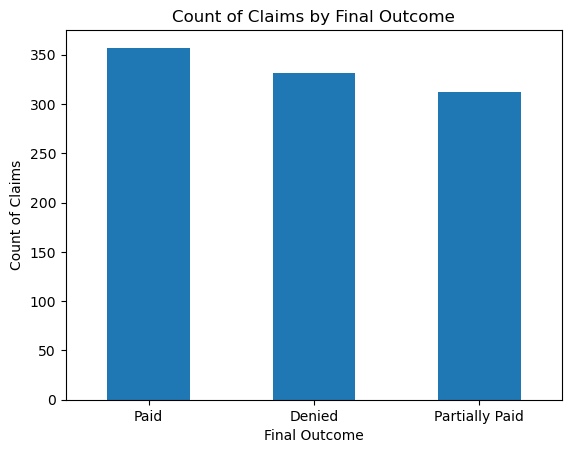

In [27]:
import matplotlib.pyplot as plt

outcome.plot(kind='bar')
plt.title('Count of Claims by Final Outcome')
plt.xlabel('Final Outcome')
plt.ylabel('Count of Claims')
plt.xticks(rotation=0)
plt.show()

According to this bar chart, the number of claims for each outcome seem fairly even so class imbalance shouldn't be an issue if I am looking into claims by outcome.  The outcome column shows the final outcome of the claim after any adjustments were made, so looking at the claim status collumn might be better to help answer my question on whether a claim is denied *initially*.

In [29]:
claim_stat = newdf['Claim Status'].value_counts()
print(claim_stat)

Claim Status
Paid            403
Denied          399
Under Review    198
Name: count, dtype: int64


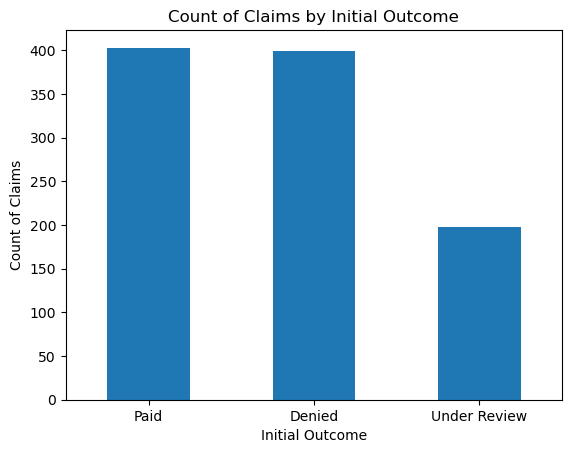

In [32]:
claim_stat.plot(kind='bar')
plt.title('Count of Claims by Initial Outcome')
plt.xlabel('Initial Outcome')
plt.ylabel('Count of Claims')
plt.xticks(rotation=0)
plt.show()

The claim status column shows a similar number of rows of each outcome so class imbalance shouldn't be a problem for this variable.  This column should be the most helpful for me to see the results of the initial outcome.

After looking through the data more, I discovered some inconsistencies with it. The data from kaggle was randomly generated, and therefore there are some things that do not make sense and need to be cleaned. First, I am only looking to see if a claim will be denieed by insurance, so I can remove any self-pay rows.

In [36]:
newdf = newdf[newdf['Insurance Type'] != 'Self-Pay']
newdf.head()

,Claim ID,Provider ID,Patient ID,Date of Service,Billed Amount,Procedure Code,Diagnosis Code,Allowed Amount,Paid Amount,Insurance Type,Claim Status,Reason Code,Follow-up Required,AR Status,Outcome
0,IUZ0VOYKNH,1355108115,6724619623,5/2/2024,374,99213,A16.3,257,237,Commercial,Paid,Incorrect billing information,No,Partially Paid,Denied
1,W7NKLL5GMD,1355108115,3896716396,7/31/2024,365,99213,A01.9,289,233,Commercial,Paid,Authorization not obtained,No,Open,Partially Paid
2,1QEU1AIDAU,1355108115,2611585318,7/4/2024,235,99213,A00.1,148,119,Commercial,Paid,Duplicate claim,No,Denied,Denied
3,BCCMJ8LJ96,1355108115,5311844927,7/2/2024,260,99213,A03.3,178,172,Medicaid,Paid,Patient eligibility issues,Yes,Denied,Denied
4,1OIRVKJHYQ,1355108115,6572802735,8/24/2024,304,99213,A04.6,234,215,Medicaid,Paid,Authorization not obtained,No,Denied,Paid


In [38]:
insurance = newdf['Insurance Type'].value_counts()
print(insurance)

Insurance Type
Commercial    259
Medicaid      259
Medicare      233
Name: count, dtype: int64


The AR Status / accounts receivable column is not necessary for the question that I am trying to answer, since it shows the status after the claim if it was already denied, so I will drop that column.  I am also not interested in the claim Id or follow up required columns.  I also do not need the allowed amount, paid amount or reason code columns either since these are determined after a claim is already paid or denied.

In [41]:
new_cols = ['Insurance Type', 'Provider ID', 'Date of Service', 'Claim Status', 'Billed Amount', 'Diagnosis Code', 'Procedure Code']
cleaned_df = newdf[new_cols].copy()
cleaned_df.head()

,Insurance Type,Provider ID,Date of Service,Claim Status,Billed Amount,Diagnosis Code,Procedure Code
0,Commercial,1355108115,5/2/2024,Paid,374,A16.3,99213
1,Commercial,1355108115,7/31/2024,Paid,365,A01.9,99213
2,Commercial,1355108115,7/4/2024,Paid,235,A00.1,99213
3,Medicaid,1355108115,7/2/2024,Paid,260,A03.3,99213
4,Medicaid,1355108115,8/24/2024,Paid,304,A04.6,99213


The reason I decided to keep the columns that I did is because of the following:  Some insurance types may be more likely to deny claims, the claim status is what we are trying to predict, maybe the billed amount by the hospital has an effect on whether a claim is denied, certain diagnosis codes might have more denials, and certain procdure codes might also be more likely to have denials.

In [44]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 751 entries, 0 to 999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Insurance Type   751 non-null    object
 1   Provider ID      751 non-null    int64 
 2   Date of Service  751 non-null    object
 3   Claim Status     751 non-null    object
 4   Billed Amount    751 non-null    int64 
 5   Diagnosis Code   751 non-null    object
 6   Procedure Code   751 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 46.9+ KB


I will need to change procedure code to an object type since it is not meant to be treated as a number and change the date to be a date type.

In [47]:
cleaned_df['Procedure Code'] = cleaned_df['Procedure Code'].astype('object')

In [49]:
cleaned_df["Date of Service"] = pd.to_datetime(cleaned_df["Date of Service"])

In [51]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 751 entries, 0 to 999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Insurance Type   751 non-null    object        
 1   Provider ID      751 non-null    int64         
 2   Date of Service  751 non-null    datetime64[ns]
 3   Claim Status     751 non-null    object        
 4   Billed Amount    751 non-null    int64         
 5   Diagnosis Code   751 non-null    object        
 6   Procedure Code   751 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 46.9+ KB


After looking through the data, I also realized that I want to just look at whether a claim is paid or denied. The "under review" data can be used at a later time to test whether they made be denied in the future, but for training purposes it doesn't add any extra information so I will remove the under review rows from the dataset.

In [54]:
filtered_df = cleaned_df[cleaned_df['Claim Status'].isin(['Paid', 'Denied'])].copy()
filtered_df.head()

,Insurance Type,Provider ID,Date of Service,Claim Status,Billed Amount,Diagnosis Code,Procedure Code
0,Commercial,1355108115,2024-05-02,Paid,374,A16.3,99213
1,Commercial,1355108115,2024-07-31,Paid,365,A01.9,99213
2,Commercial,1355108115,2024-07-04,Paid,235,A00.1,99213
3,Medicaid,1355108115,2024-07-02,Paid,260,A03.3,99213
4,Medicaid,1355108115,2024-08-24,Paid,304,A04.6,99213


Another visualization that I think could be helpful to look at is a comparison box plot between denied and paid claims, and where the billed amount lies to see if that could potentially have an effect on the claim status.

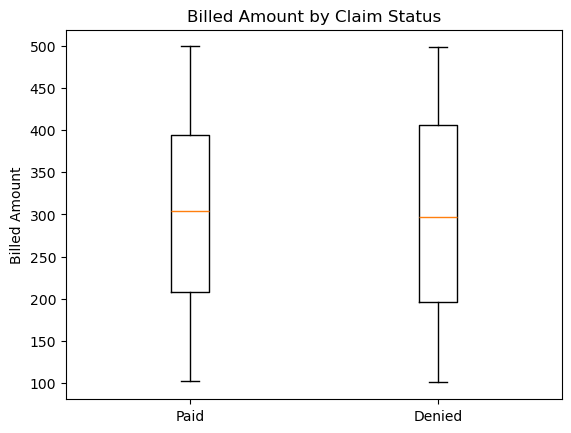

In [57]:
paid = filtered_df[filtered_df['Claim Status'] == 'Paid']['Billed Amount']
denied = filtered_df[filtered_df['Claim Status'] == 'Denied']['Billed Amount']

plt.boxplot([paid, denied], tick_labels=['Paid', 'Denied'])
plt.title('Billed Amount by Claim Status')
plt.ylabel('Billed Amount')
plt.show()

The boxplots for billed amount differenecs between paid and denied claims look fairly similar. There aren't any obvious outliers in the data set, but the denied claim does have a wider spread of billed amount data and might show some extra variability in denied claims.

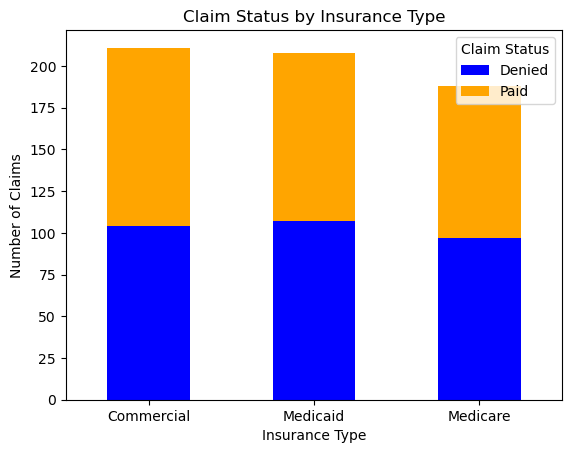

In [60]:
claims = pd.crosstab(filtered_df['Insurance Type'], filtered_df['Claim Status'])

claims.plot(kind='bar', stacked=True, color=['blue', 'orange'])
plt.title('Claim Status by Insurance Type')
plt.xlabel('Insurance Type')
plt.ylabel('Number of Claims')
plt.xticks(rotation=0)
plt.show()

First, I am going to see how a deicison tree model works with the data

In [63]:
df = filtered_df.copy()

Since I have categorical columns in my data set, I will use dummy variables in order to be able to create a model with these variables. I also split the date of service column in order to see if there might be a difference based on month or day of the week whether a claim is denied or paid.  The Diagnosis code also has the letter A in the beginning of it which isn't adding anything meaningful, so I removed the A and added the code as just a number so that it will not need to be made into dummy variables.

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn import tree

The procedure code and provider ID will need to be made into dummy variables and changed to string format first.

In [68]:
df["Month"] = df["Date of Service"].dt.month
df["Weekday"] = df["Date of Service"].dt.weekday
df = df.drop("Date of Service", axis=1)

df["Diagnosis_Num"] = df["Diagnosis Code"].astype(str).str.extract(r'(\d+\.\d+|\d+)').astype(float)
df = df.drop("Diagnosis Code", axis=1)

df["Procedure_Code"] = df["Procedure Code"].astype(str)
df = df.drop("Procedure Code", axis=1)

df["Provider_ID"] = df["Provider ID"].astype(str)
df = df.drop("Provider ID", axis=1)

In [69]:
df.head()

,Insurance Type,Claim Status,Billed Amount,Month,Weekday,Diagnosis_Num,Procedure_Code,Provider_ID
0,Commercial,Paid,374,5,3,16.3,99213,1355108115
1,Commercial,Paid,365,7,2,1.9,99213,1355108115
2,Commercial,Paid,235,7,3,0.1,99213,1355108115
3,Medicaid,Paid,260,7,1,3.3,99213,1355108115
4,Medicaid,Paid,304,8,5,4.6,99213,1355108115


Based on the new df above, there are 3 categorical columns which will need to be one-hot encoded for logistic regregssion including the Provider ID, Procedure code and insurance type. The claim status column will be the target for the model.

In [71]:
categorical_cols = ["Insurance Type", "Procedure_Code", "Provider_ID"]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

I also want to switch the claim status column to numbers since it is currently categorical and will not work in decision tree models if it stays categorical. 

In [77]:
df["Claim Status"] = df["Claim Status"].map({"Denied": 0, "Paid": 1})

Next I will split the data into test and training data, and fit a decision tree on the training data. Then I will compare it to the testing data. I decided to use 20% vs 80% to split my data into test and training since I have a smaller amount of data to work with.

In [80]:
X = df.drop("Claim Status", axis=1)
y = df["Claim Status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [82]:
dt = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42)
dt.fit(X_train, y_train)


DecisionTreeClassifier(class_weight='balanced', max_depth=6,
                       min_samples_split=5, random_state=42)

In [84]:
y_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.48360655737704916

Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.58      0.53        62
           1       0.47      0.38      0.42        60

    accuracy                           0.48       122
   macro avg       0.48      0.48      0.48       122
weighted avg       0.48      0.48      0.48       122


Confusion Matrix:
 [[36 26]
 [37 23]]


According to the above results, the accuracy was only around 48% which is not great. The confusion matrix shows that 36 claims were accurately predicted as denied, but only 23 were accurately predicted as being paid with around 63 claims getting incorrectly identified. Based on this, I think that a random forest model might help to get better results since it will create many different decision trees and should increase the accuracy and should help fix the imbalance in my current model (where mostly denied claims are predicted).

**RANDOM FOREST**

In [88]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


I will use the df that I had beforer with the same categorical columns and one-hot encoding for the random forest model and keep the training and testing data at 80% vs 20%.

In [91]:
X = df.drop("Claim Status", axis=1)
y = df["Claim Status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [93]:
rf = RandomForestClassifier(
    n_estimators=200,          # number of trees
    max_depth=8,               # limit tree depth
    min_samples_split=5,
    class_weight='balanced',   # handle imbalance
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8,
                       min_samples_split=5, n_estimators=200, random_state=42)

In [95]:
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.4918032786885246

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.50      0.50        62
           1       0.48      0.48      0.48        60

    accuracy                           0.49       122
   macro avg       0.49      0.49      0.49       122
weighted avg       0.49      0.49      0.49       122


Confusion Matrix:
 [[31 31]
 [31 29]]


After running the random forest model, the accuracy barely increased, although the split between the number of correctly identified denials and correctly identified paid claims was more even this time.  The data that I found for this was randomly generated, and I think that because of this there may not be any patterns in the data necessarily and not enough data to find one so any model that I use will most likely not predict things correctly.

With this in mind, I think that I will use a new data set found on kaggle that contains information on denied/paid claims and more information about the patients that may help me find patterns and create a more accurate model.

****NEW DATA SET BELOW****

In [99]:
df = pd.read_csv("enhanced_health_insurance_claims.csv")
df.head()

,ClaimID,PatientID,ProviderID,ClaimAmount,ClaimDate,DiagnosisCode,ProcedureCode,PatientAge,PatientGender,ProviderSpecialty,ClaimStatus,PatientIncome,PatientMaritalStatus,PatientEmploymentStatus,ProviderLocation,ClaimType,ClaimSubmissionMethod
0,10944daf-f7d5-4e1d-8216-72ffa609fe41,8552381d-7960-4f64-b190-b20b8ada00a1,4a4cb19c-4863-41cf-84b0-c2b21aace988,3807.95,6/7/2024,yy006,hd662,16,M,Cardiology,Approved,90279.43,Married,Retired,Jameshaven,Routine,Paper
1,fcbebb25-fc24-4c0f-a966-749edcf83fb1,327f43ad-e3bd-4473-a9ed-46483a0a156f,422e02dd-c1fd-43dd-8af4-0c3523f997b1,9512.07,5/30/2023,tD052,mH831,27,M,Pediatrics,Approved,130448.02,Single,Student,Beltrantown,Routine,Online
2,9e9983e7-9ea7-45f5-84d8-ce49ccd8a4a1,6f3acdf7-73aa-4afa-9c2e-b25b27bdb5b0,f7733b3f-0980-47b5-a7a0-ee390869355b,7346.74,9/27/2022,zx832,dg637,40,F,Cardiology,Approved,82417.54,Divorced,Employed,West Charlesport,Emergency,Online
3,a06273ed-44bb-452b-bbad-8618de080494,5d58e183-701e-406c-a8c6-5b73cac5e912,f7a04581-de96-44ee-b773-8adac02baa59,6026.72,6/25/2023,kr421,kG326,65,M,Neurology,Denied,68516.96,Widowed,Student,West Aprilhaven,Routine,Phone
4,f702a717-254b-4cff-a0c7-8395db2f6616,8a8ebdf6-3af0-4f14-82f3-37b937c3d270,b80b9e77-97f0-47d7-b561-19f9658a7bdf,1644.58,7/24/2023,LZ261,cx805,24,M,General Practice,Approved,84122.17,Married,Student,Lake Michele,Inpatient,Phone


This data set contains a lot more information including patient marital status, gender, claim type, age, income and more. There are also many more rows in this data set which will be helpful for me to find a pattern and make a predictive model based on this data. 

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ClaimID                  4500 non-null   object 
 1   PatientID                4500 non-null   object 
 2   ProviderID               4500 non-null   object 
 3   ClaimAmount              4500 non-null   float64
 4   ClaimDate                4500 non-null   object 
 5   DiagnosisCode            4500 non-null   object 
 6   ProcedureCode            4500 non-null   object 
 7   PatientAge               4500 non-null   int64  
 8   PatientGender            4500 non-null   object 
 9   ProviderSpecialty        4500 non-null   object 
 10  ClaimStatus              4500 non-null   object 
 11  PatientIncome            4500 non-null   float64
 12  PatientMaritalStatus     4500 non-null   object 
 13  PatientEmploymentStatus  4500 non-null   object 
 14  ProviderLocation        

In [104]:
df["ClaimDate"] = pd.to_datetime(df["ClaimDate"])

In [106]:
df.describe()

,ClaimAmount,ClaimDate,PatientAge,PatientIncome
count,4500.000000,4500,4500.000000,4500.000000
mean,5014.203867,2023-07-05 06:48:38.400000,49.838444,84384.284084
min,100.120000,2022-07-09 00:00:00,0.000000,20006.870000
25%,2509.072500,2023-01-07 18:00:00,25.000000,52791.905000
50%,5053.765000,2023-07-03 00:00:00,50.500000,84061.205000
75%,7462.452500,2023-12-29 00:00:00,75.000000,115768.417500
max,9997.200000,2024-07-08 00:00:00,99.000000,149957.520000
std,2866.291066,NaN,28.790471,37085.908878


I also want to check if there are any null values within this data set that might affect my future analysis.

In [109]:
print(df.isnull().sum())

ClaimID                    0
PatientID                  0
ProviderID                 0
ClaimAmount                0
ClaimDate                  0
DiagnosisCode              0
ProcedureCode              0
PatientAge                 0
PatientGender              0
ProviderSpecialty          0
ClaimStatus                0
PatientIncome              0
PatientMaritalStatus       0
PatientEmploymentStatus    0
ProviderLocation           0
ClaimType                  0
ClaimSubmissionMethod      0
dtype: int64


An issue that I had previously was with there being a lack of paid claim status types, so I want to see what the various status types are.  I would also like to see how many of each type of status there are in the data.

In [112]:
df['ClaimStatus'].unique()

array(['Approved', 'Denied', 'Pending'], dtype=object)

In [114]:
stat = df['ClaimStatus'].value_counts()
print(stat)

ClaimStatus
Denied      1688
Approved    1670
Pending     1142
Name: count, dtype: int64


There seems to be a fairly even split of denied and approved status claim types in the data.

I also would like to see if there is any difference in denials based on claim type.

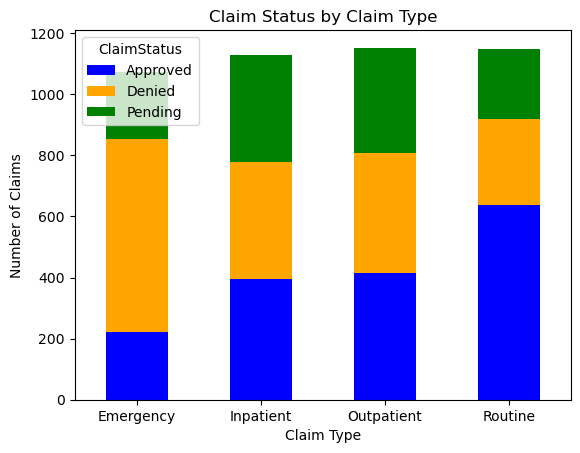

In [118]:
newclaims = pd.crosstab(df['ClaimType'], df['ClaimStatus'])

newclaims.plot(kind='bar', stacked=True, color=['blue', 'orange', 'green'])
plt.title('Claim Status by Claim Type')
plt.xlabel('Claim Type')
plt.ylabel('Number of Claims')
plt.xticks(rotation=0)
plt.show()

According to the above, there seems to be larger number of denied claims specifically for emergencies, and a larger number of accepted claims for routine ones.

Next I want to see a distribution on patient income to see how the income might vary for the entire data set.

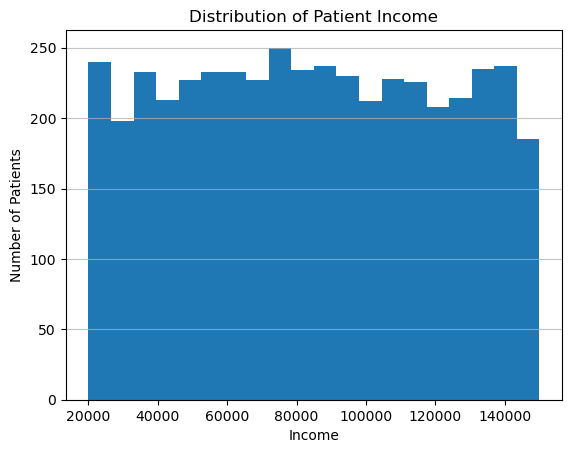

In [121]:
plt.hist(df['PatientIncome'], bins=20)
plt.title('Distribution of Patient Income')
plt.xlabel('Income')
plt.ylabel('Number of Patients')
plt.grid(axis='y', alpha=0.75)
plt.show()

This histogram shows me that there is a fairly even distribution of patient income in this data set.

For the new data set, I would also like to try a decision tree (and maybe random forest and logistic regression) as my model to predict claim outcomes. In order to set up my data for this I will need to drop columns that I will not need for modeling like the ID columns assuming that these might be mainly individual. I am also going to see how the data set does without the date column in it since I do not have an end date and am not sure how much the month or day of the week might actually affect the claims status.

In [125]:
columns = ['ClaimAmount', 'DiagnosisCode', 'ProcedureCode', 'PatientAge', 'PatientGender', 'ProviderSpecialty', 'ClaimStatus', 'PatientIncome', 'PatientMaritalStatus', 'PatientEmploymentStatus', 'ProviderLocation', 'ClaimType', 'ClaimSubmissionMethod']
newdf = df[columns].copy()
newdf.head()

,ClaimAmount,DiagnosisCode,ProcedureCode,PatientAge,PatientGender,ProviderSpecialty,ClaimStatus,PatientIncome,PatientMaritalStatus,PatientEmploymentStatus,ProviderLocation,ClaimType,ClaimSubmissionMethod
0,3807.95,yy006,hd662,16,M,Cardiology,Approved,90279.43,Married,Retired,Jameshaven,Routine,Paper
1,9512.07,tD052,mH831,27,M,Pediatrics,Approved,130448.02,Single,Student,Beltrantown,Routine,Online
2,7346.74,zx832,dg637,40,F,Cardiology,Approved,82417.54,Divorced,Employed,West Charlesport,Emergency,Online
3,6026.72,kr421,kG326,65,M,Neurology,Denied,68516.96,Widowed,Student,West Aprilhaven,Routine,Phone
4,1644.58,LZ261,cx805,24,M,General Practice,Approved,84122.17,Married,Student,Lake Michele,Inpatient,Phone


I also only will want to see which claims are approved and denied and am not interested in the pending claim status items.

In [128]:
newdf = newdf[newdf['ClaimStatus'].isin(['Approved', 'Denied'])].copy()
newdf.head()

,ClaimAmount,DiagnosisCode,ProcedureCode,PatientAge,PatientGender,ProviderSpecialty,ClaimStatus,PatientIncome,PatientMaritalStatus,PatientEmploymentStatus,ProviderLocation,ClaimType,ClaimSubmissionMethod
0,3807.95,yy006,hd662,16,M,Cardiology,Approved,90279.43,Married,Retired,Jameshaven,Routine,Paper
1,9512.07,tD052,mH831,27,M,Pediatrics,Approved,130448.02,Single,Student,Beltrantown,Routine,Online
2,7346.74,zx832,dg637,40,F,Cardiology,Approved,82417.54,Divorced,Employed,West Charlesport,Emergency,Online
3,6026.72,kr421,kG326,65,M,Neurology,Denied,68516.96,Widowed,Student,West Aprilhaven,Routine,Phone
4,1644.58,LZ261,cx805,24,M,General Practice,Approved,84122.17,Married,Student,Lake Michele,Inpatient,Phone


In [130]:
newdf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3358 entries, 0 to 4499
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ClaimAmount              3358 non-null   float64
 1   DiagnosisCode            3358 non-null   object 
 2   ProcedureCode            3358 non-null   object 
 3   PatientAge               3358 non-null   int64  
 4   PatientGender            3358 non-null   object 
 5   ProviderSpecialty        3358 non-null   object 
 6   ClaimStatus              3358 non-null   object 
 7   PatientIncome            3358 non-null   float64
 8   PatientMaritalStatus     3358 non-null   object 
 9   PatientEmploymentStatus  3358 non-null   object 
 10  ProviderLocation         3358 non-null   object 
 11  ClaimType                3358 non-null   object 
 12  ClaimSubmissionMethod    3358 non-null   object 
dtypes: float64(2), int64(1), object(10)
memory usage: 367.3+ KB


I will once again list out my categorical columns for my new data set in order to use dummy variables/one hot encoding.

In [133]:
categorical_cols = ['DiagnosisCode', 'ProcedureCode', 'PatientGender', 'ProviderSpecialty', 'PatientMaritalStatus', 'PatientEmploymentStatus', 'ProviderLocation', 'ClaimType', 'ClaimSubmissionMethod']

newdf = pd.get_dummies(newdf, columns=categorical_cols, drop_first=True)

In [135]:
newdf["ClaimStatus"] = newdf["ClaimStatus"].map({"Denied": 0, "Approved": 1})

*Explain your process for prepping the data*

For the data set that I ended up using for this project, I first looked at the rows and the data types of the various columns.  I changed data types, checked for any null values and made sure that the new data set contained information on both paid and denied claims.  I also made sure that there wasn’t an imbalance of the claim types that would have an adverse effect on the model later. 

After cleaning the data a little, I created some visualizations in order to see if I can understand more about the current state of the data.  I looked at the distribution of patient income to see if the income was spread out or more concentrated.  I also checked the number of each claim status (paid, denied or in process) depending on the claim type (inpatient, outpatient, emergency, routine).  This visualization showed that emergency claims had more denials and that there were more approved routine claims than any other type of claim.   

After visualizing some of the data, I started to prepare it for modeling.  I removed columns that did not add any value for modeling including all of the ID columns.  I also decided to remove the date column since I did not have an end date listed and was not sure how much it would help.  I filtered the data set so that I would only see approved or denied claims since I am not interested in claims that are only in progress.   I then determined which columns were categorical and created dummy variables for those columns. 

**New dataset decision tree model**

In [138]:
X = newdf.drop(columns=['ClaimStatus'])
y = newdf['ClaimStatus'] 

I am still using an 80/20 split on the data for testing and training data and will first test a decision tree to see if accuracy might be higher with this data set.

In [141]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [143]:
dtc = DecisionTreeClassifier(max_depth=5, random_state=42)
dtc.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [145]:
accuracy = dtc.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.6755952380952381


The accuracy of this model is much higher with the new data as compared to the old data but still not great (less than 70%).

I want to see if changing the max depth of the tree from 5 to 10 might help improve accuracy of this decision tree model in case it is too limited.

In [149]:
dtc2 = DecisionTreeClassifier(max_depth=10, random_state=42)
dtc2.fit(X_train, y_train)
print(dtc2.score(X_test, y_test))

0.6130952380952381


Accuracy decreased when I added depth to the tree from 5 to 10. This was a large jump, so I want to see how a depth of 7 would change the accuracy of the model. 

In [152]:
dtc3 = DecisionTreeClassifier(max_depth=7, random_state=42)
dtc3.fit(X_train, y_train)
print(dtc3.score(X_test, y_test))

0.6502976190476191


**Build and evaluate at least one model**

The first model that I decided to try was a decision tree model.  I split the data into testing and training data, with testing data being 20% of the data set and used a depth of 5.  I calculated the accuracy of the model which ended up being 67%, which was not great. I decided to see if changing the depth of the tree could help improve accuracy.  A depth of 10 ended up decreasing the accuracy to 61% and a depth of 7 led to accuracy of 65% which was still less than my original tree.  This analysis led me to believe that some features within the data are not good predictors of claim denials.  

The accuracy was still lower at a depth of 7, so more depth does not lead to a higher accuracy. This makes me believe that some features are good predictors of claim denials and others are not.

Next I want to see if using a random forest model would lead to a higher accuracy since it uses many decision trees rather than just one. I will use 300 estimators and see how the accuracy changes. I made sure to add the class_weight = 'balanced' part so that both dennied and approved claims will have the same weight.

In [155]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
rfc.fit(X_train, y_train)
print(rfc.score(X_test, y_test))

0.6473214285714286


I then decided to use a random forest model to see if the accuracy might improve.  With 300 estimators, the accuracy of the random forest model ended up being 64% which is lower than the decision tree.  Random forest models are ensemble models that can help reduce overfitting, so I wonder if my decision tree model was slightly overfit causing the higher accuracy. I decided to continue to use random forest and see if I could create some feature engineering that would help improve accuracy.

In [157]:
newdf.head()

,ClaimAmount,PatientAge,ClaimStatus,PatientIncome,DiagnosisCode_AB512,DiagnosisCode_AD070,DiagnosisCode_AE486,DiagnosisCode_AE653,DiagnosisCode_AE967,DiagnosisCode_AE993,...,ProviderLocation_Yubury,ProviderLocation_Yustad,ProviderLocation_Yvetteburgh,ProviderLocation_Zacharyland,ProviderLocation_Zacharyville,ClaimType_Inpatient,ClaimType_Outpatient,ClaimType_Routine,ClaimSubmissionMethod_Paper,ClaimSubmissionMethod_Phone
0,3807.95,16,1,90279.43,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,9512.07,27,1,130448.02,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,7346.74,40,1,82417.54,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,6026.72,65,0,68516.96,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
4,1644.58,24,1,84122.17,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True


When I started looking at my data set with the dummy variables, I realized that I had over 9000 columns in the data set which could have been making it difficult for the model to make accurate predictions.  I checked the number of unique variables in each column, and discovered that the patient income, diagnosis code, procedure code, claim amount and provider location columns contained a lot of unique values.  I had expected the code columns to have less codes, but instead it seems that every line contained a different value.  It makes sense that the claim amount and patient income columns would have different numbers since people make different amounts of money and claim amount can be affected by many different variables. These are also numeric columns that were not converted to dummy variables.  I was also surprised to see that there were so many different locations and originally assumed that the data would be from only a few different places.  After discovering this information, I dropped the code columns and the location column since they did not provide enough value for the model.  The data set with the dummy variables had a significantly smaller number of columns after making these changes to the data set.

In [159]:
columns = ['ClaimAmount', 'DiagnosisCode', 'ProcedureCode', 'PatientAge', 'PatientGender', 'ProviderSpecialty', 'ClaimStatus', 'PatientIncome', 'PatientMaritalStatus', 'PatientEmploymentStatus', 'ProviderLocation', 'ClaimType', 'ClaimSubmissionMethod']
mydf = df[columns].copy()
mydf.head(25)

,ClaimAmount,DiagnosisCode,ProcedureCode,PatientAge,PatientGender,ProviderSpecialty,ClaimStatus,PatientIncome,PatientMaritalStatus,PatientEmploymentStatus,ProviderLocation,ClaimType,ClaimSubmissionMethod
0,3807.95,yy006,hd662,16,M,Cardiology,Approved,90279.43,Married,Retired,Jameshaven,Routine,Paper
1,9512.07,tD052,mH831,27,M,Pediatrics,Approved,130448.02,Single,Student,Beltrantown,Routine,Online
2,7346.74,zx832,dg637,40,F,Cardiology,Approved,82417.54,Divorced,Employed,West Charlesport,Emergency,Online
3,6026.72,kr421,kG326,65,M,Neurology,Denied,68516.96,Widowed,Student,West Aprilhaven,Routine,Phone
4,1644.58,LZ261,cx805,24,M,General Practice,Approved,84122.17,Married,Student,Lake Michele,Inpatient,Phone
5,1644.35,qM187,no581,57,M,Pediatrics,Approved,95286.87,Widowed,Student,Lake Robert,Outpatient,Paper
6,675.03,tZ864,hJ616,40,M,Neurology,Denied,44580.09,Divorced,Unemployed,Morenoton,Inpatient,Paper
7,8675.14,wO325,RD702,5,M,Cardiology,Approved,137118.00,Married,Unemployed,South Andrew,Inpatient,Online
8,6051.04,rW725,da104,74,F,General Practice,Approved,107644.30,Divorced,Student,Blackburnfurt,Inpatient,Online
9,7109.92,ss584,UE642,37,M,Neurology,Denied,102324.96,Single,Retired,South Gloriachester,Outpatient,Paper


I created a new df with the columns that I want to look into further to see which ones have too many unique values. In the future, I definitely will want to look into this before creating a model rather than assuming that the columns aren't filled with unique values.

In [161]:
mydf.nunique().sort_values(ascending=False)

PatientIncome              4500
DiagnosisCode              4495
ProcedureCode              4495
ClaimAmount                4490
ProviderLocation           3876
PatientAge                  100
ProviderSpecialty             5
PatientMaritalStatus          4
PatientEmploymentStatus       4
ClaimType                     4
ClaimStatus                   3
ClaimSubmissionMethod         3
PatientGender                 2
dtype: int64

After looking at the above, I think that I need to drop the code columns since they are not helping the model find patterns and the location since there are too many unique locations for my data set.

In [164]:
columns = ['ClaimAmount', 'PatientAge', 'PatientGender', 'ProviderSpecialty', 'ClaimStatus', 'PatientIncome', 'PatientMaritalStatus', 'PatientEmploymentStatus', 'ClaimType', 'ClaimSubmissionMethod']
mydf = df[columns].copy()
mydf.head(15)

,ClaimAmount,PatientAge,PatientGender,ProviderSpecialty,ClaimStatus,PatientIncome,PatientMaritalStatus,PatientEmploymentStatus,ClaimType,ClaimSubmissionMethod
0,3807.95,16,M,Cardiology,Approved,90279.43,Married,Retired,Routine,Paper
1,9512.07,27,M,Pediatrics,Approved,130448.02,Single,Student,Routine,Online
2,7346.74,40,F,Cardiology,Approved,82417.54,Divorced,Employed,Emergency,Online
3,6026.72,65,M,Neurology,Denied,68516.96,Widowed,Student,Routine,Phone
4,1644.58,24,M,General Practice,Approved,84122.17,Married,Student,Inpatient,Phone
5,1644.35,57,M,Pediatrics,Approved,95286.87,Widowed,Student,Outpatient,Paper
6,675.03,40,M,Neurology,Denied,44580.09,Divorced,Unemployed,Inpatient,Paper
7,8675.14,5,M,Cardiology,Approved,137118.00,Married,Unemployed,Inpatient,Online
8,6051.04,74,F,General Practice,Approved,107644.30,Divorced,Student,Inpatient,Online
9,7109.92,37,M,Neurology,Denied,102324.96,Single,Retired,Outpatient,Paper


In [165]:
mydf = mydf[mydf['ClaimStatus'].isin(['Approved', 'Denied'])].copy()
mydf.head()

mydf["ClaimStatus"] = mydf["ClaimStatus"].map({"Denied": 0, "Approved": 1})

categorical_columns = ['PatientGender', 'ProviderSpecialty', 'PatientMaritalStatus', 'PatientEmploymentStatus', 'ClaimType', 'ClaimSubmissionMethod']
mydf_withdummies = pd.get_dummies(mydf, columns=categorical_columns, drop_first=True)

mydf_withdummies.head()

,ClaimAmount,PatientAge,ClaimStatus,PatientIncome,PatientGender_M,ProviderSpecialty_General Practice,ProviderSpecialty_Neurology,ProviderSpecialty_Orthopedics,ProviderSpecialty_Pediatrics,PatientMaritalStatus_Married,PatientMaritalStatus_Single,PatientMaritalStatus_Widowed,PatientEmploymentStatus_Retired,PatientEmploymentStatus_Student,PatientEmploymentStatus_Unemployed,ClaimType_Inpatient,ClaimType_Outpatient,ClaimType_Routine,ClaimSubmissionMethod_Paper,ClaimSubmissionMethod_Phone
0,3807.95,16,1,90279.43,True,False,False,False,False,True,False,False,True,False,False,False,False,True,True,False
1,9512.07,27,1,130448.02,True,False,False,False,True,False,True,False,False,True,False,False,False,True,False,False
2,7346.74,40,1,82417.54,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,6026.72,65,0,68516.96,True,False,True,False,False,False,False,True,False,True,False,False,False,True,False,True
4,1644.58,24,1,84122.17,True,True,False,False,False,True,False,False,False,True,False,True,False,False,False,True


In [166]:
X = mydf_withdummies.drop(columns=['ClaimStatus'])
y = mydf_withdummies['ClaimStatus'] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

mydt = DecisionTreeClassifier(max_depth=5, random_state=42)
mydt.fit(X_train, y_train)

accuracy = mydt.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.6755952380952381


I decided to re-try my decision tree model to see if the accuracy would change after dropping the extra columns, but it remained at 67%.  I also decided to try the random forest model again with the extra columns removed and accuracy decreased to 62%.  Accuracy is not always the best metric to determine how well your model is working since you may be looking for different things depending on the question you are trying to answer. For example, I am looking to try and limit the number of claims that get denied, which means that I want to catch as many potentially problematic claims as possible before they are submitted.  This means that accuracy might not be the best metric to use and that a confusion matrix could help understand what is happening behind the scenes and why accuracy is higher for the decision tree model. 

In [167]:
mydf_withdummies.shape[1]

20

Below, the confusion matrix for the decision tree model is in blue and the confusion matrix for the random forest model is in green.   Both models accurately predicted a similar number of denied claims that were actually denied and both predicted a similar number of claims to be approved that were actually denied, which I am trying to limit.
If I had only used accuracy as my metric, I wouldn’t have noticed that both models were actually predicting similar numbers for the claims that are actually denied.


Decision Tree Confusion Matrix:
 [[238 120]
 [ 98 216]]


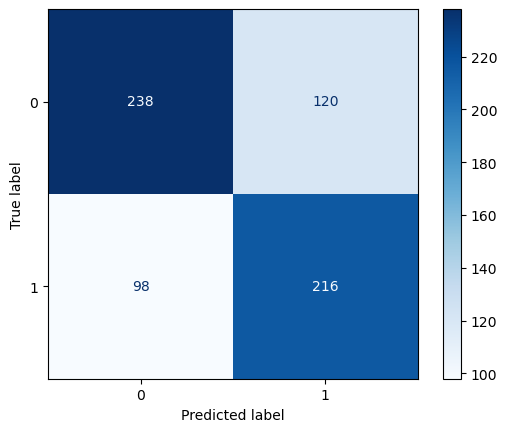

In [168]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_mydt = mydt.predict(X_test)
cm_mydt = confusion_matrix(y_test, y_pred_mydt)
print("Decision Tree Confusion Matrix:\n", cm_mydt)

disp_mydt = ConfusionMatrixDisplay(confusion_matrix=cm_mydt, display_labels=mydt.classes_)
disp_mydt.plot(cmap='Blues')

The accuracy remained the same for the decision tree model with the extra columns removed which proves that the columns were not adding any value to the model. next I will try random forest again to see if that accuracy also remains the same and will compare the confusion matrices for both models.

In [170]:
X = mydf_withdummies.drop(columns=['ClaimStatus'])
y = mydf_withdummies['ClaimStatus'] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

myrf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
myrf.fit(X_train, y_train)
print(myrf.score(X_test, y_test))

0.6235119047619048


The accuracy of the random forest model went down after removing the columns, but I still don't think that they were adding much value to the model and the higher accuracy before may have been the result of a lucky guess by the model.

Random Forest Confusion Matrix:
 [[233 125]
 [128 186]]


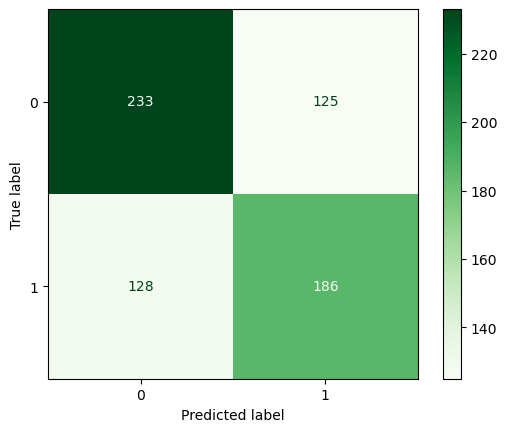

In [172]:
y_pred_rf = myrf.predict(X_test)

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Random Forest Confusion Matrix:\n", cm_rf)

disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=myrf.classes_)
disp_rf.plot(cmap='Greens')

The accuracy of the decision tree model is 5% higher and the confusion matrix shows that the decision tree predicts a similar number of denied claims as the random forest, but the decision tree also predicts more approved claims accurately. There are also less claims in the decision tree model that are predicted to be denied and turn out to not be denied. 

After analyzing the confusion matrices, I started utilizing feature creation to try and improve my models’ results.  I created some extra features including a column that compared claim amount to a patient’s income, a column that grouped ages together and a column that concatenated claim type and provider specialty together.  I created a new data frame with new dummy variables and re-made the confusion matrices to see how they changed and also calculated the F1 score, precision and recall of both models to compare.

In [175]:
columns = ['ClaimAmount', 'PatientAge', 'PatientGender', 'ProviderSpecialty', 'ClaimStatus', 'PatientIncome', 'PatientMaritalStatus', 'PatientEmploymentStatus', 'ClaimType', 'ClaimSubmissionMethod']
feature_df = df[columns].copy()
feature_df = feature_df[feature_df['ClaimStatus'].isin(['Approved', 'Denied'])]
feature_df.head(15)

,ClaimAmount,PatientAge,PatientGender,ProviderSpecialty,ClaimStatus,PatientIncome,PatientMaritalStatus,PatientEmploymentStatus,ClaimType,ClaimSubmissionMethod
0,3807.95,16,M,Cardiology,Approved,90279.43,Married,Retired,Routine,Paper
1,9512.07,27,M,Pediatrics,Approved,130448.02,Single,Student,Routine,Online
2,7346.74,40,F,Cardiology,Approved,82417.54,Divorced,Employed,Emergency,Online
3,6026.72,65,M,Neurology,Denied,68516.96,Widowed,Student,Routine,Phone
4,1644.58,24,M,General Practice,Approved,84122.17,Married,Student,Inpatient,Phone
5,1644.35,57,M,Pediatrics,Approved,95286.87,Widowed,Student,Outpatient,Paper
6,675.03,40,M,Neurology,Denied,44580.09,Divorced,Unemployed,Inpatient,Paper
7,8675.14,5,M,Cardiology,Approved,137118.00,Married,Unemployed,Inpatient,Online
8,6051.04,74,F,General Practice,Approved,107644.30,Divorced,Student,Inpatient,Online
9,7109.92,37,M,Neurology,Denied,102324.96,Single,Retired,Outpatient,Paper


In [176]:
feature_df['ClaimAmountToIncome'] = feature_df['ClaimAmount'] / feature_df['PatientIncome']

feature_df['AgeGroup'] = pd.cut(feature_df['PatientAge'], bins=[0, 18, 35, 50, 65, 100],
                        labels=['Child', 'YoungAdult', 'Adult', 'MiddleAge', 'Senior'])

feature_df['ClaimType_Specialty'] = (feature_df['ClaimType'].astype(str) + "_" + feature_df['ProviderSpecialty'].astype(str))

In [193]:
feature_df.head()

,ClaimAmount,PatientAge,PatientGender,ProviderSpecialty,ClaimStatus,PatientIncome,PatientMaritalStatus,PatientEmploymentStatus,ClaimType,ClaimSubmissionMethod,ClaimAmountToIncome,AgeGroup,ClaimType_Specialty
0,3807.95,16,M,Cardiology,Approved,90279.43,Married,Retired,Routine,Paper,0.042180,Child,Routine_Cardiology
1,9512.07,27,M,Pediatrics,Approved,130448.02,Single,Student,Routine,Online,0.072918,YoungAdult,Routine_Pediatrics
2,7346.74,40,F,Cardiology,Approved,82417.54,Divorced,Employed,Emergency,Online,0.089140,Adult,Emergency_Cardiology
3,6026.72,65,M,Neurology,Denied,68516.96,Widowed,Student,Routine,Phone,0.087960,MiddleAge,Routine_Neurology
4,1644.58,24,M,General Practice,Approved,84122.17,Married,Student,Inpatient,Phone,0.019550,YoungAdult,Inpatient_General Practice


I can remove some columns now that I have created some new features as well

In [196]:
feature_df  = feature_df.drop(columns=['PatientAge', 'ClaimType', 'ProviderSpecialty'])
feature_df.head()

,ClaimAmount,PatientGender,ClaimStatus,PatientIncome,PatientMaritalStatus,PatientEmploymentStatus,ClaimSubmissionMethod,ClaimAmountToIncome,AgeGroup,ClaimType_Specialty
0,3807.95,M,Approved,90279.43,Married,Retired,Paper,0.042180,Child,Routine_Cardiology
1,9512.07,M,Approved,130448.02,Single,Student,Online,0.072918,YoungAdult,Routine_Pediatrics
2,7346.74,F,Approved,82417.54,Divorced,Employed,Online,0.089140,Adult,Emergency_Cardiology
3,6026.72,M,Denied,68516.96,Widowed,Student,Phone,0.087960,MiddleAge,Routine_Neurology
4,1644.58,M,Approved,84122.17,Married,Student,Phone,0.019550,YoungAdult,Inpatient_General Practice


In [198]:
dummy_cols = ['PatientGender', 'PatientMaritalStatus', 'PatientEmploymentStatus', 'ClaimSubmissionMethod', 'AgeGroup', 'ClaimType_Specialty']

feature_df_dummies = pd.get_dummies(feature_df, columns=dummy_cols, drop_first=True)

Random Forest Accuracy: 0.6339285714285714
              precision    recall  f1-score   support

    Approved       0.60      0.66      0.63       314
      Denied       0.67      0.61      0.64       358

    accuracy                           0.63       672
   macro avg       0.64      0.64      0.63       672
weighted avg       0.64      0.63      0.63       672



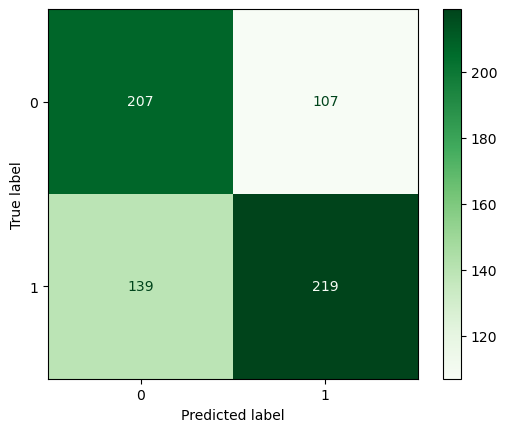

In [200]:
X = feature_df_dummies.drop(columns=['ClaimStatus'])
y = feature_df_dummies['ClaimStatus']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", rf.score(X_test, y_test))

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf).plot(cmap='Greens')

Decision Tree Accuracy: 0.5639880952380952
              precision    recall  f1-score   support

    Approved       0.53      0.59      0.56       314
      Denied       0.60      0.54      0.57       358

    accuracy                           0.56       672
   macro avg       0.57      0.57      0.56       672
weighted avg       0.57      0.56      0.56       672



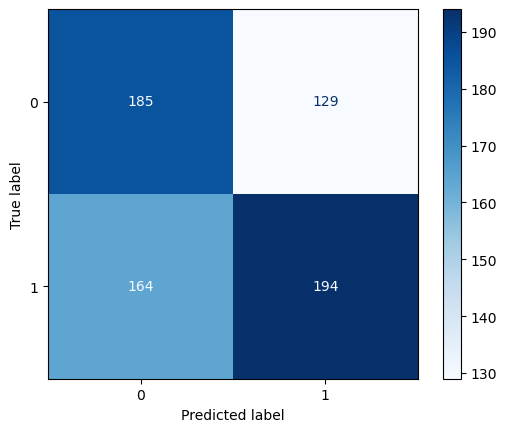

In [202]:
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", dt.score(X_test, y_test))

print(classification_report(y_test, y_pred_dt))

cm_dt = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(cm_dt).plot(cmap='Blues')

After creating new features, the random forest model accuracy actually increased and the decision tree model accuracy decreased.  The confusion matrices show that the random forest model was better at predicting actually denied claims as denied and actually approved claims as approved.  The decision tree model also predicted more approved claims as denied, and more denied claims as being approved which is not what I am looking for.  This leads me to believe more that the decision tree model might have been overfit since new features decreased accuracy and led to the decision to just use the random forest model from now on. 

Since I care more about catching the denied claims, I will try and tune my random forest model to catch the denied claims and label them as more important.  I reset the model below and tried to tune some of the parameters:

New Random Forest Accuracy: 0.6086309523809523
              precision    recall  f1-score   support

    Approved       0.57      0.64      0.61       314
      Denied       0.65      0.58      0.61       358

    accuracy                           0.61       672
   macro avg       0.61      0.61      0.61       672
weighted avg       0.61      0.61      0.61       672



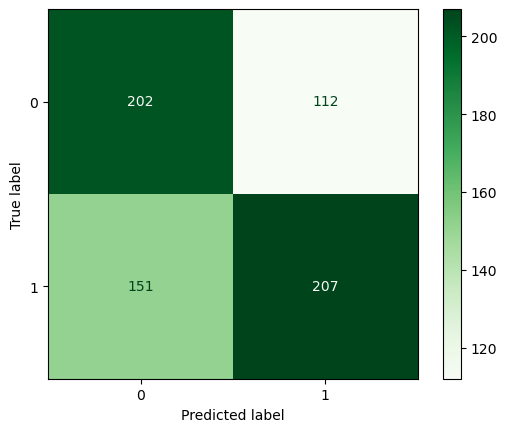

In [209]:
X = feature_df_dummies.drop(columns=['ClaimStatus'])
y = feature_df_dummies['ClaimStatus']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#the class weight is changing below from balanced to adding more importance to denied claims
rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight={'Approved': 1, 'Denied': 2})
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("New Random Forest Accuracy:", rf.score(X_test, y_test))

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf).plot(cmap='Greens')

After making the denied claims more important, the accuracy and prediction of denied claims got worse, so I think it is better to keep it as a balanced data set. Something else that I would like to try is to see if I can lower the threshhold to determining whether a claim is denied. 

In [212]:
X = feature_df_dummies.drop(columns=['ClaimStatus'])
y = feature_df_dummies['ClaimStatus']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

I wasn't sure how to change the threshold and found an example online here:

hpaulj. (2018, April 11). How to set threshold to scikit-learn random forest model [Answer]. Stack Overflow. https://stackoverflow.com/questions/49785904/how-to-set-threshold-to-scikit-learn-random-forest-model

In [215]:
y_proba = rf.predict_proba(X_test)

print(rf.classes_)

['Approved' 'Denied']


In [217]:
threshold = 0.4
y_pred_thresh = ['Denied' if p[rf.classes_ == 'Denied'][0] >= threshold else 'Approved' for p in y_proba]

              precision    recall  f1-score   support

    Approved       0.65      0.42      0.51       314
      Denied       0.61      0.80      0.69       358

    accuracy                           0.62       672
   macro avg       0.63      0.61      0.60       672
weighted avg       0.63      0.62      0.61       672



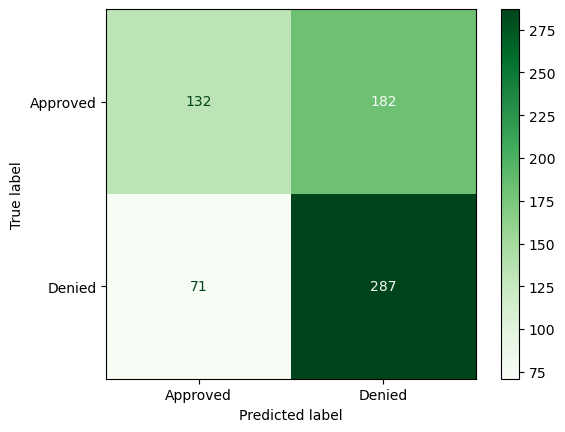

In [219]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(classification_report(y_test, y_pred_thresh))

cm = confusion_matrix(y_test, y_pred_thresh)
ConfusionMatrixDisplay(cm, display_labels=rf.classes_).plot(cmap='Greens')

Now that I decided on a random forest model, I tried to tune the model so that I could catch as many denied claims as possible.  I tried changing the class weight to make denied claims more important however this ended up making the accuracy and prediction of denied claims worse, so I decided to keep the class weight balanced.  Next I tried to lower the threshold for predicting denied claims to 0.4 rather than 0.5 to see how that would affect the model.  Changing the threshold would make it so that if the model is 40% confident that the claim is denied, it will label it as denied (instead of being 50% confident). Once I made this change, the model was able to accurately predict almost 300 claims to be denied.  Changing the threshold also means that the number of approved claims that are inaccurately being labeled as denied would increase as well however, and this number increased to almost 200.   Only 71 denied claims were labeled as approved after making this change which is better than it was before. 

Next I want to see if I can tune the model even more using ROC curves and GridSearchCV to see if I can tune the hyperparameters more.

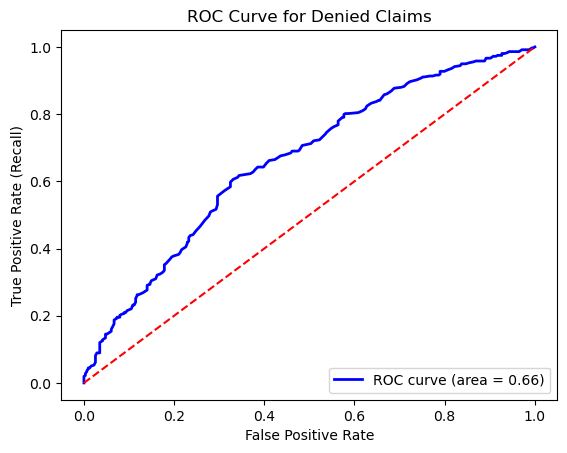

In [225]:
from sklearn.metrics import roc_curve, auc

denied_idx = list(rf.classes_).index('Denied')
y_denied_proba = y_proba[:, denied_idx]

fpr, tpr, thresholds = roc_curve(y_test, y_denied_proba, pos_label='Denied')
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve for Denied Claims')
plt.legend(loc='lower right')
plt.show()

According to the ROC curve and area under it, the model is not great at separating denied and approved claims, but it is better than random guessing for the denied claims.  The best threshold looks like it is between 0.3 and 0.4, so I will try changing the threshold to 0.375.

              precision    recall  f1-score   support

    Approved       0.31      0.16      0.21       314
      Denied       0.48      0.68      0.56       358

    accuracy                           0.44       672
   macro avg       0.39      0.42      0.39       672
weighted avg       0.40      0.44      0.40       672



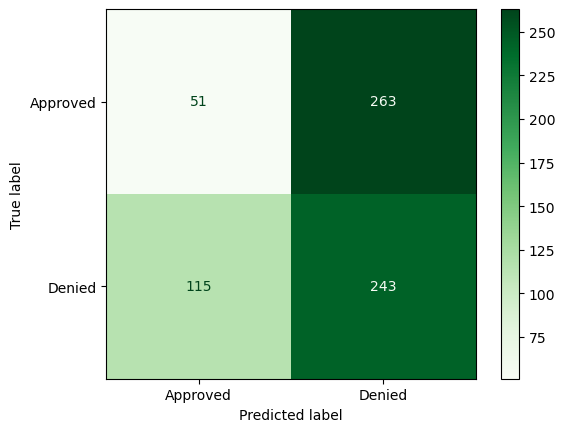

In [230]:
threshold = 0.375
y_pred_thresh = ['Denied' if p[0] >= threshold else 'Approved' for p in y_proba]
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(classification_report(y_test, y_pred_thresh))

cm = confusion_matrix(y_test, y_pred_thresh)
ConfusionMatrixDisplay(cm, display_labels=rf.classes_).plot(cmap='Greens')

When I tried changing the threshold to 0.375 it led to more approved claims being incorrectly classified as denied.  This change would decrease the efficiency of the model, so I decide to stick with 0.4 as my threshold.

Next I want to see if I can tune the parameters with grid search. I mainly care about the recall for denied claims more than the recall for the positive claims so I made the positive label to be denied. I chose to do 5 for the cross fold validation 

In [234]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, recall_score

recall_denied = make_scorer(recall_score, pos_label='Denied')

param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'max_features': [0.3, 0.5, 0.7, None] 
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid=param_grid,
    scoring=recall_denied, 
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best params:", grid_rf.best_params_)
print("Best denied recall):", grid_rf.best_score_)

Best params: {'max_depth': None, 'max_features': 0.3, 'min_samples_leaf': 5, 'min_samples_split': 20, 'n_estimators': 500}
Best denied recall): 0.6323308270676692


Last, I tried using GridSearchCV to tune the model’s parameters.  In this scenario, I care more about the recall for denied claims than I do for the approved claims so I made the positive label denied rather than approved.  After testing various different numbers of estimators, depths and more, the best parameters ended up being the following: 

In [235]:
best_rf = grid_rf.best_estimator_
print(best_rf)

RandomForestClassifier(class_weight='balanced', max_features=0.3,
                       min_samples_leaf=5, min_samples_split=20,
                       n_estimators=500, random_state=42)


In [236]:
y_pred_test = best_rf.predict(X_test)
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

    Approved       0.64      0.64      0.64       314
      Denied       0.69      0.69      0.69       358

    accuracy                           0.67       672
   macro avg       0.66      0.66      0.66       672
weighted avg       0.67      0.67      0.67       672



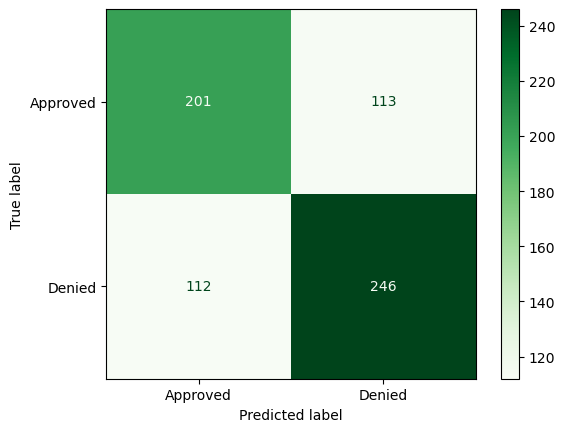

In [237]:
y_pred = best_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm, display_labels=best_rf.classes_).plot(cmap='Greens')

After refining the parameters, the model predictions are more balanced however I think that it is missing too many denied claims. Using the refined model, I will decrease the threshold to 0.4 once again and test the new confusion matrix.

Using the best parameters to tune my random forest model and lowering the threshold to 0.4 left me with a high denied recall of 0.83

In [239]:
import numpy as np

y_proba_denied = best_rf.predict_proba(X_test)[:, best_rf.classes_ == 'Denied'].ravel()
 
threshold = 0.4
y_pred_cust = np.where(y_proba_denied >= threshold, 'Denied', 'Approved')

print(classification_report(y_test, y_pred_cust))

              precision    recall  f1-score   support

    Approved       0.68      0.41      0.51       314
      Denied       0.62      0.83      0.71       358

    accuracy                           0.63       672
   macro avg       0.65      0.62      0.61       672
weighted avg       0.65      0.63      0.62       672



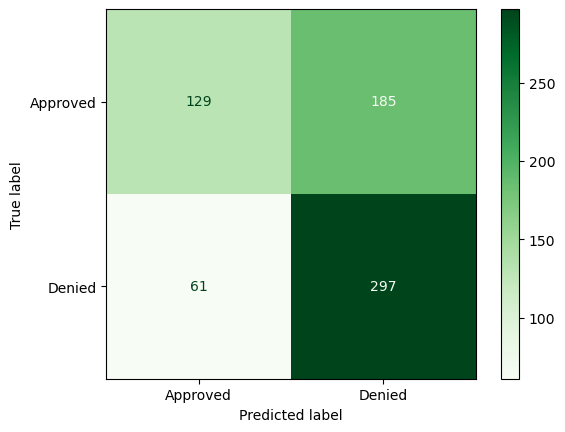

In [240]:
cm_cust = confusion_matrix(y_test, y_pred_cust)

ConfusionMatrixDisplay(cm_cust, display_labels=best_rf.classes_).plot(cmap='Greens')

Although at this point the accuracy of the model is 63%, the recall for denied claims is 83% which means that the model catches 83% of denied claims.  More approved claims are misslabeled as denied, but since we are trying to prevent claims from being denied (since it can be costly for a hospital and the patient) the latest model would be best. This model makes it so that we can catch most of the claims that are getting denied without having to go through every single claim to see what the problem is. This model helps to narrow down which claims could be problematic and will need to be reviewed.

This tuned model had the best balanced confusion matrix that I could create. Almost 300 out of around 350 denied claims were accurately predicted, with 61 getting mislabeled as approved when they were actually denied.  129 approved claims were accurately predicted as approved, and 185 approved claims were mislabeled as denied. Although this model inaccurately predicts a high number of denied claims that are actually approved, it catches most of the denied claims and had a high recall along with a higher number of approved claims being accurately labeled as approved.

**Results and Findings Explained**

**Interpreting Results**

I checked the most important feature of the model and the most influential one ended up being the claim amount to income column that I created.  The claim amount and patient income features also had a big influence on the model’s decision making.  After these two, the amount of influence that other features have on the model drops significantly.  A paper submission method also has some influence, but not as much as the income and claim amount do. The chart below shows the features and their influence on the random forest model’s decision making.

In [244]:
importances = best_rf.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

                                            Feature  Importance
2                               ClaimAmountToIncome    0.153375
0                                       ClaimAmount    0.145594
1                                     PatientIncome    0.141867
10                      ClaimSubmissionMethod_Paper    0.062921
34           ClaimType_Specialty_Routine_Pediatrics    0.047501
33          ClaimType_Specialty_Routine_Orthopedics    0.039036
19         ClaimType_Specialty_Emergency_Pediatrics    0.038461
17          ClaimType_Specialty_Emergency_Neurology    0.030343
31     ClaimType_Specialty_Routine_General Practice    0.029469
16   ClaimType_Specialty_Emergency_General Practice    0.023444
4                      PatientMaritalStatus_Married    0.018592
3                                   PatientGender_M    0.017962
15                                  AgeGroup_Senior    0.017084
18        ClaimType_Specialty_Emergency_Orthopedics    0.016651
7                   PatientEmploymentSta

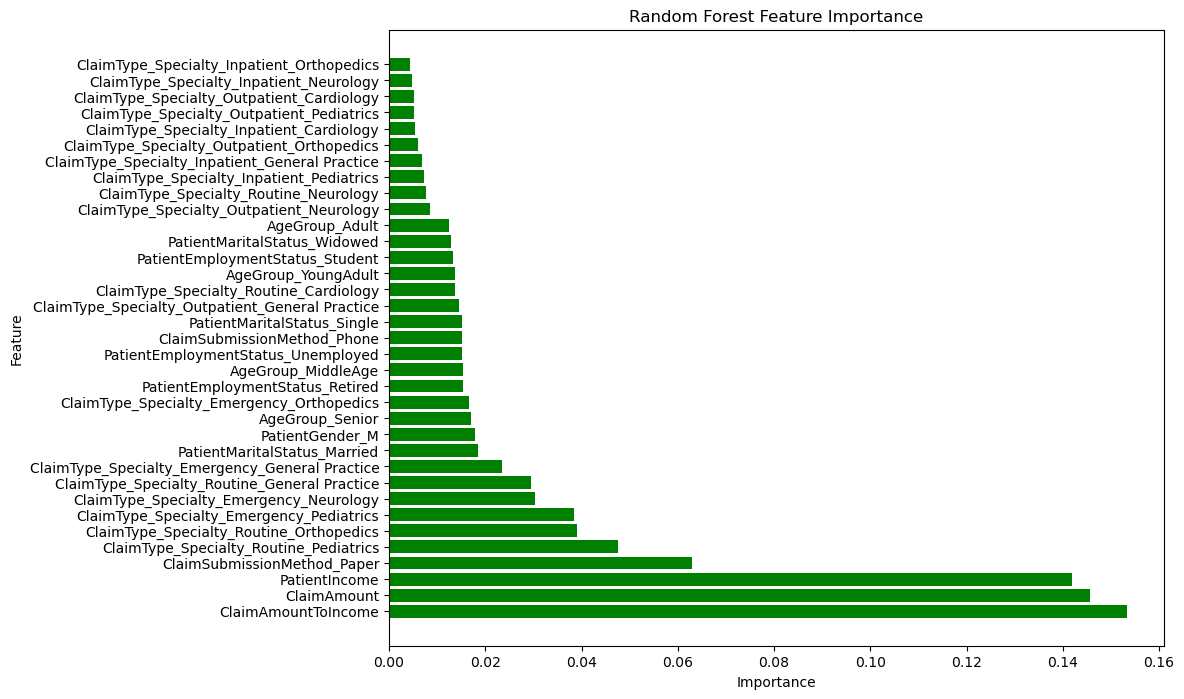

In [245]:
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='green')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

According to the above, claim amount to income is the most important predictor of whether a claim gets denied or approved, along with claim amount and patient ncome separately. A paper claim submission method is also a high indicator, but it doesnt have nearly as much influence as the other features.

**Conclusion**

The model did not have the highest accuracy metric at only 63% however it was able to accurately predict denied claims 83% of the time. The recall for the approved class was only 41% though which shows that the model favors the denied class.   In this scenario, it is more important to capture as many denied claims as possible since we are trying to fix these claims before they get submitted in order to help patients get their care in a timely manner and for hospitals and private practices to get reimbursed on time.  
	The features that were most important had to do with financial information including claim amount and a patients income, and a comparison between these two variables.  This suggests that these features have the most influence on whether a claim will be denied.  The model does have room for improvement in order to increase accuracy more and to increase recall for approved claims in order to not waste time re-checking claims that would get approved however it is better than just double checking every single claim. Adding more features to the dataset, trying other models and cleaning the data more could potentially increase model performance in the future.  I would recommend gathering more data to test the model on and to keep evaluating the model and tuning the parameters in order to get the best results and to decrease false positives and false negatives. 


I would say that this model is not yet ready for deployment.  I think that the model could be tuned even further with more time and can eventually be used by a hospital or private practice. 

*Analyze the ethical implications of the project*

Some ethical implications could be bias towards patients that have certain income levels.  Private practices might use the information to determine which patients they decide to see which would be wrong and discriminatory.  It is important to ensure that the results of this model would not affect the treatment of the patients and would only be used as a way to determine which medical claims might be at higher risk of getting denied the first time around in order to help patients and improve claim timeliness.  The model should also be used as a guideline to help flag claims that may get denied, rather than ones that will definitely be denied.  An expert should also evaluate the results and use their experience with claim denials to determine if a claim really may be denied or not and if there are any errors. The model should also be updated over time in order to adjust it if there are new policies or if a new metric appears that has an influence on a claim’s likeliness to be denied.  As always, patient health care data should be secured and access only by authorized users and must remain in compliance with HIPAA laws.
 


*What did you learn?*

I learned a lot while completing this project about searching for data, cleaning data and how to tune models.  I also learned a lot about how to make sure that the model is accurate and that sometimes accuracy is not the best metric for a model depending on the question you are trying to answer.  Not all data will have trends that can be easily found and can easily be turned into a data model and sometimes you have to dig to find patterns using feature engineering.  I also learned how long it can take to make a model that can be used in production and how much work goes into tuning them as well.

**References**

Frank, E. L. (2018, October 18). Understanding the F1 score. Medium. https://ellielfrank.medium.com/understanding-the-f1-score-55371416fbe1

hpaulj. (2018, April 11). How to set threshold to scikit-learn random forest model [Answer]. Stack Overflow. https://stackoverflow.com/questions/49785904/how-to-set-threshold-to-scikit-learn-random-forest-model

Patino, C. M., & Ferreira, J. C. (2021). Recall bias. In StatPearls [Internet]. StatPearls Publishing. https://www.ncbi.nlm.nih.gov/books/NBK557812/

Ranked, C. (2023, December 4). Common reasons for insurance claims denials. EnableComp. https://enablecomp.com/denial-prevention-and-resolution/reasons-for-denial/#:~:text=Incorrect%20or%20duplicate%20claims%2C%20lack,also%20likely%20to%20be%20denied. 

Steinzor, P., & Grossi, G. (2025, February 27). How insurance claim denials harm patients’ health, finances. AJMC. https://www.ajmc.com/view/how-insurance-claim-denials-harm-patients-health-finances 
